In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json

## CNN6

### Loss и Accuracy

#### Предобучение

In [30]:
f = open("statistics/CNN6_baseline_pretrain.json")
baseline_stat = json.load(f)

f = open("statistics/CNN6_ortho_pretrain.json")
ortho_stat = json.load(f)

f = open("statistics/CNN6_pc_not_0_0.1_pretrain.json")
pc_stat = json.load(f)

f = open("statistics/CNN6_f_cov_pretrain.json")
f_cov_stat = json.load(f)

Text(0.5, 0.98, 'На тестовой выборке')

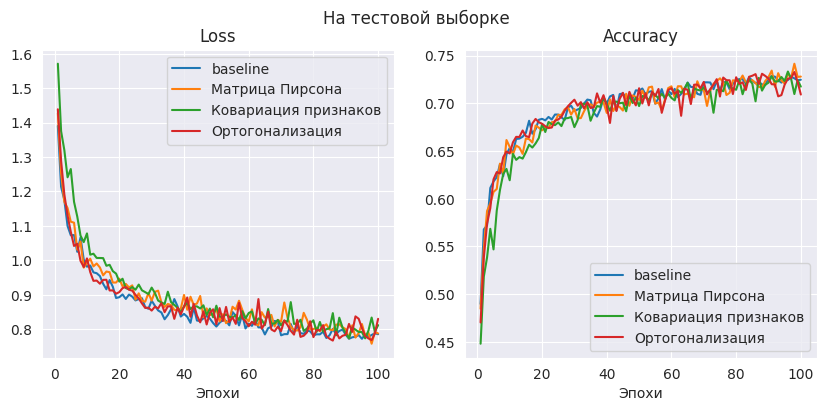

In [33]:
fix, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(baseline_stat['test_idx'], baseline_stat["test_loss"], label="baseline")
ax[0].plot(pc_stat['test_idx'], pc_stat["test_loss"], label="Матрица Пирсона")
ax[0].plot(f_cov_stat['test_idx'], f_cov_stat["test_loss"], label="Ковариация признаков")
ax[0].plot(ortho_stat['test_idx'], ortho_stat["test_loss"], label="Ортогонализация")
ax[0].legend()
ax[0].set_title("Loss")
ax[0].set_xlabel("Эпохи")

ax[1].plot(baseline_stat['test_idx'], baseline_stat["test_accuracy"], label="baseline")
ax[1].plot(pc_stat['test_idx'], pc_stat["test_accuracy"], label="Матрица Пирсона")
ax[1].plot(f_cov_stat['test_idx'], f_cov_stat["test_accuracy"], label="Ковариация признаков")
ax[1].plot(ortho_stat['test_idx'], ortho_stat["test_accuracy"], label="Ортогонализация")
ax[1].legend()
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Эпохи")

fix.suptitle("На тестовой выборке")

#### Дообучение

In [20]:
f = open("statistics/CNN6_baseline_quant.json")
baseline_stat = json.load(f)

f = open("statistics/CNN6_pc_not_0_0.1_quant.json")
pc_stat = json.load(f)

f = open("statistics/CNN6_ortho_quant.json")
ortho_stat = json.load(f)

f = open("statistics/CNN6_f_cov_quant.json")
f_cov_stat = json.load(f)

Text(0.5, 0.98, 'На тестовой выборке')

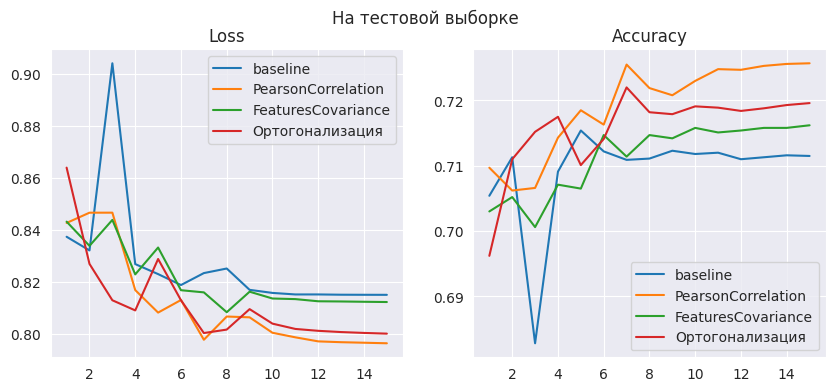

In [21]:
fix, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(baseline_stat['test_idx'], baseline_stat["test_loss"], label="baseline")
ax[0].plot(pc_stat['test_idx'], pc_stat["test_loss"], label="PearsonCorrelation")
ax[0].plot(f_cov_stat['test_idx'], f_cov_stat["test_loss"], label="FeaturesCovariance")
ax[0].plot(ortho_stat['test_idx'], ortho_stat["test_loss"], label="Ортогонализация")
ax[0].legend()
ax[0].set_title("Loss")

ax[1].plot(baseline_stat['test_idx'], baseline_stat["test_accuracy"], label="baseline")
ax[1].plot(pc_stat['test_idx'], pc_stat["test_accuracy"], label="PearsonCorrelation")
ax[1].plot(f_cov_stat['test_idx'], f_cov_stat["test_accuracy"], label="FeaturesCovariance")
ax[1].plot(ortho_stat['test_idx'], ortho_stat["test_accuracy"], label="Ортогонализация")
ax[1].legend()
ax[1].set_title("Accuracy")

fix.suptitle("На тестовой выборке")

## Проекции

In [4]:
f = open("statistics/CNN6_baseline_proj_pretrain_max_proj.json")
baseline_proj = json.load(f)

f = open("statistics/CNN6_ortho_proj_pretrain_max_proj.json")
ortho_proj = json.load(f)

conv_layers = ["conv1", "conv2", "conv3", "fc1"]

# fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
# for l_i, layer in enumerate(conv_layers):
#     ax[0].plot(baseline_proj[l_i], label=layer)
#     ax[1].plot(ortho_proj[l_i], label=layer)
#
# ax[1].legend(bbox_to_anchor=(1.1, 1.05))
# # fig.suptitle("Максимальная норма проекции ближайших фильтров")
# ax[1].set_title("Ортогонализация")
# ax[0].set_title("Нет ортогонализации")
# ax[0].set_xlabel("Шаги")
# ax[1].set_xlabel("Шаги")
# ax[0].grid(True)
# ax[1].grid(True)

print("baseline")
for l_i, layer in enumerate(conv_layers):
    print(layer, baseline_proj[l_i][-1])

print("ortho")
for l_i, layer in enumerate(conv_layers):
    print(layer, ortho_proj[l_i][-1])


baseline
conv1 0.9695433974266052
conv2 1.030174732208252
conv3 1.115955114364624
fc1 1.3439997434616089
ortho
conv1 0.6020899415016174
conv2 0.9499971866607666
conv3 0.9377214908599854
fc1 1.057415246963501


### Corrls

#### Предобучение

In [5]:
f = open("statistics/CNN6_baseline_pretrain_corrls_L.json")
baseline_stat = json.load(f)

f = open("statistics/CNN6_pc_not_0_0.1_pretrain_corrls_L.json")
pc_stat = json.load(f)

f = open("statistics/CNN6_ortho_pretrain_corrls_L.json")
ortho_stat = json.load(f)

f = open("statistics/CNN6_f_cov_pretrain_corrls_L.json")
f_cov_stat = json.load(f)

In [36]:
len(pc_stat["corrs_l"])

5

In [6]:
conv_layers = ["conv0", "conv1", "conv2", "conv3", "fc1"]

In [8]:
print("baseline")
for l_i, layer in enumerate(conv_layers):
    print(layer, baseline_stat["corrs_l"][l_i][-1])

print("ortho")
for l_i, layer in enumerate(conv_layers):
    print(layer, ortho_stat["corrs_l"][l_i][-1])

print("pc_not_0")
for l_i, layer in enumerate(conv_layers):
    print(layer, pc_stat["corrs_l"][l_i][-1])

print("f_cov")
for l_i, layer in enumerate(conv_layers):
    print(layer, f_cov_stat["corrs_l"][l_i][-1])

baseline
conv0 0.5220982617767962
conv1 0.34690549334499804
conv2 0.34107548828591366
conv3 0.25485808191088527
fc1 0.33381362027737016
ortho
conv0 0.645931645305976
conv1 0.22109413496769764
conv2 0.3404215357846725
conv3 0.2354209195578039
fc1 0.30566604807439474
pc_not_0
conv0 0.57732728840448
conv1 0.010004721162106447
conv2 0.013893142162994095
conv3 0.007847967091206018
fc1 0.00781806658682087
f_cov
conv0 0.6002908592057906
conv1 0.37112925496602456
conv2 0.3005068178680371
conv3 0.26011542404725985
fc1 0.35213019672580165


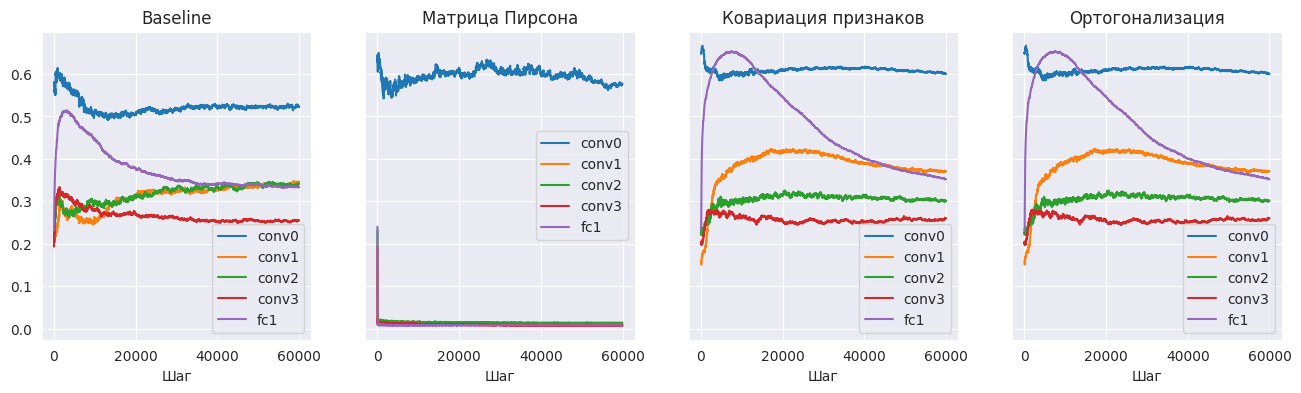

In [100]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
# fig.suptitle("Corrs_L для слоев")

axs[0].set_title("Baseline")
for i, layer_name in enumerate(conv_layers):
    axs[0].plot(baseline_stat["corrs_l"][i], label=layer_name)
axs[0].legend()
axs[0].set_xlabel("Шаг")

axs[1].set_title("Матрица Пирсона")
for i, layer_name in enumerate(conv_layers):
    axs[1].plot(pc_stat["corrs_l"][i], label=layer_name)
axs[1].legend()
axs[1].set_xlabel("Шаг")

axs[2].set_title("Ковариация признаков")
for i, layer_name in enumerate(conv_layers):
    axs[2].plot(f_cov_stat["corrs_l"][i], label=layer_name)
axs[2].legend()
axs[2].set_xlabel("Шаг")

axs[3].set_title("Ортогонализация")
for i, layer_name in enumerate(conv_layers):
    axs[3].plot(f_cov_stat["corrs_l"][i], label=layer_name)
axs[3].legend()
axs[3].set_xlabel("Шаг")

print()

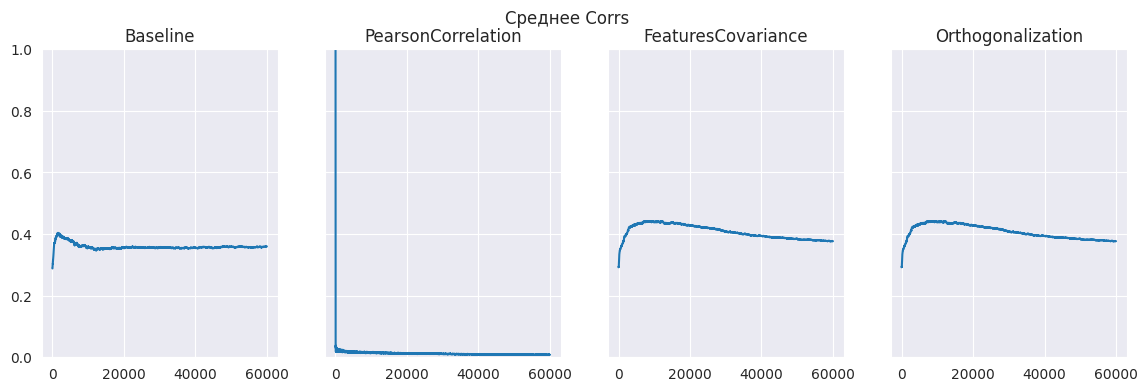

In [41]:
fig, axs = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
fig.suptitle("Среднее Corrs")

axs[0].set_title("Baseline")
axs[0].plot(baseline_stat["mean_corrs"])
axs[0].set_ylim((0, 1))

axs[1].set_title("PearsonCorrelation")
axs[1].plot(pc_stat["mean_corrs"])

axs[2].set_title("FeaturesCovariance")
axs[2].plot(f_cov_stat["mean_corrs"])

axs[3].set_title("Orthogonalization")
axs[3].plot(f_cov_stat["mean_corrs"])

print()

#### Дообучение

In [43]:
f = open("statistics/CNN6_baseline_quant_corrls_L.json")
baseline_stat = json.load(f)

f = open("statistics/CNN6_pc_not_0_0.1_quant_corrls_L.json")
pc_stat = json.load(f)

f = open("statistics/CNN6_f_cov_quant_corrls_L.json")
f_cov_stat = json.load(f)

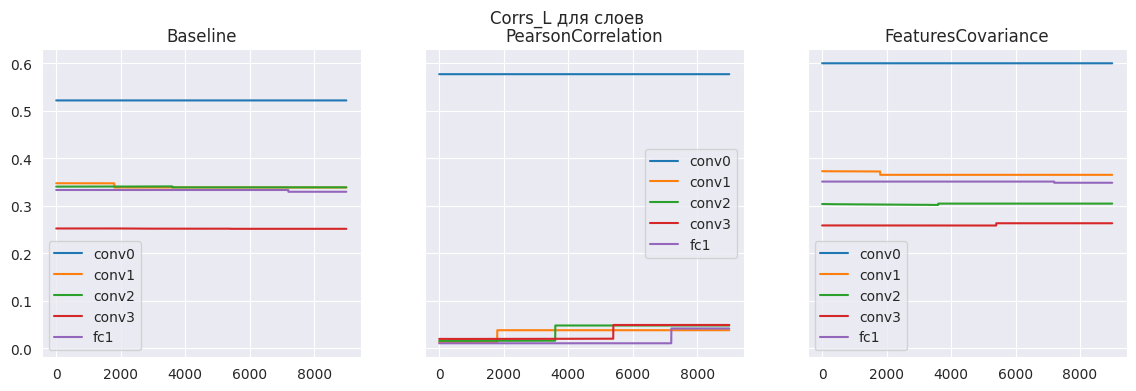

In [44]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Corrs_L для слоев")
k = 4
axs[0].set_title("Baseline")
for i, layer_name in enumerate(conv_layers):
    axs[0].plot(baseline_stat["corrs_l"][i], label=layer_name)
# m = max(baseline_stat["corrs_l"][k])
# axs[0].plot(np.array(baseline_stat["corrs_l"][k]) / m)
axs[0].legend()

axs[1].set_title("PearsonCorrelation")
for i, layer_name in enumerate(conv_layers):
    axs[1].plot(pc_stat["corrs_l"][i], label=layer_name)
# m = max(pc_stat["corrs_l"][k])
# axs[1].plot(np.array(pc_stat["corrs_l"][k]) / m)
axs[1].legend()

axs[2].set_title("FeaturesCovariance")
for i, layer_name in enumerate(conv_layers):
    axs[2].plot(f_cov_stat["corrs_l"][i], label=layer_name)
# m = max(f_cov_stat["corrs_l"][k])
# axs[2].plot(np.array(f_cov_stat["corrs_l"][k]) / m)
axs[2].legend()

print()

### Матрицы Пирсона

#### Предобучение

In [9]:
from cifar_models import CNN6
import torch

model_baseline = CNN6()
model_baseline.load_state_dict(torch.load("models/CNN6_baseline_pretrain.pt", weights_only=True))
model_baseline.eval()

model_ortho = CNN6()
model_ortho.load_state_dict(torch.load("models/CNN6_ortho_pretrain.pt", weights_only=True))
model_ortho.eval()

model_pc = CNN6()
model_pc.load_state_dict(torch.load("models/CNN6_pc_not_0_0.1_pretrain.pt", weights_only=True))
model_pc.eval()

model_f_cov = CNN6()
model_f_cov.load_state_dict(torch.load("models/CNN6_f_cov_pretrain.pt", weights_only=True))
model_f_cov.eval()

print()

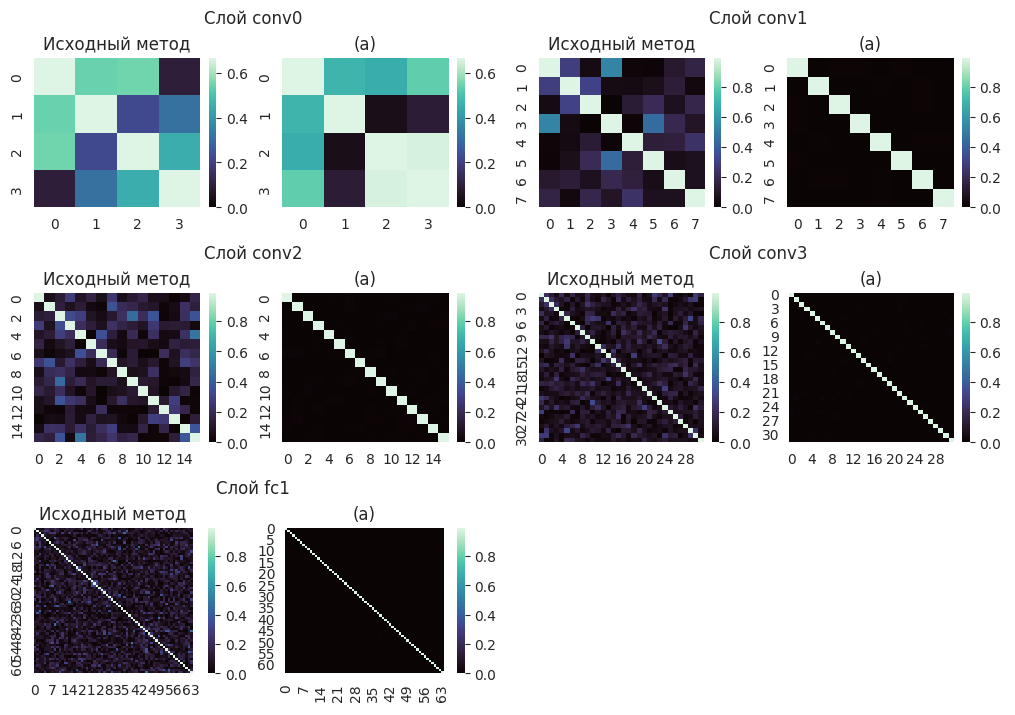

In [10]:
import seaborn as sns
from PearsonCorrelation import pearson_correlation_mat

fig = plt.figure(constrained_layout=True, figsize=(10, 7))
# fig.suptitle('Матрицы Пирсона для сверток после предобучения baseline vs PearsonCorrelation')
subfigs = fig.subfigures(nrows=3, ncols=2)

with torch.no_grad():
    for i, layer in enumerate(model_pc.conv_layers):
        sup_ax = subfigs[i // 2][i % 2].subplots(1, 2)
        pm_bl = pearson_correlation_mat(model_baseline.get_submodule(f"{layer}").get_weight())
        pm_pc = pearson_correlation_mat(model_pc.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_bl.abs(), cmap="mako", vmin=0, ax=sup_ax[0])
        sup_ax[0].set_title("Исходный метод")
        sns.heatmap(pm_pc.abs(), cmap="mako", vmin=0, ax=sup_ax[1])
        sup_ax[1].set_title("(a)")
        subfigs[i // 2][i % 2].suptitle(f"Слой {layer}")

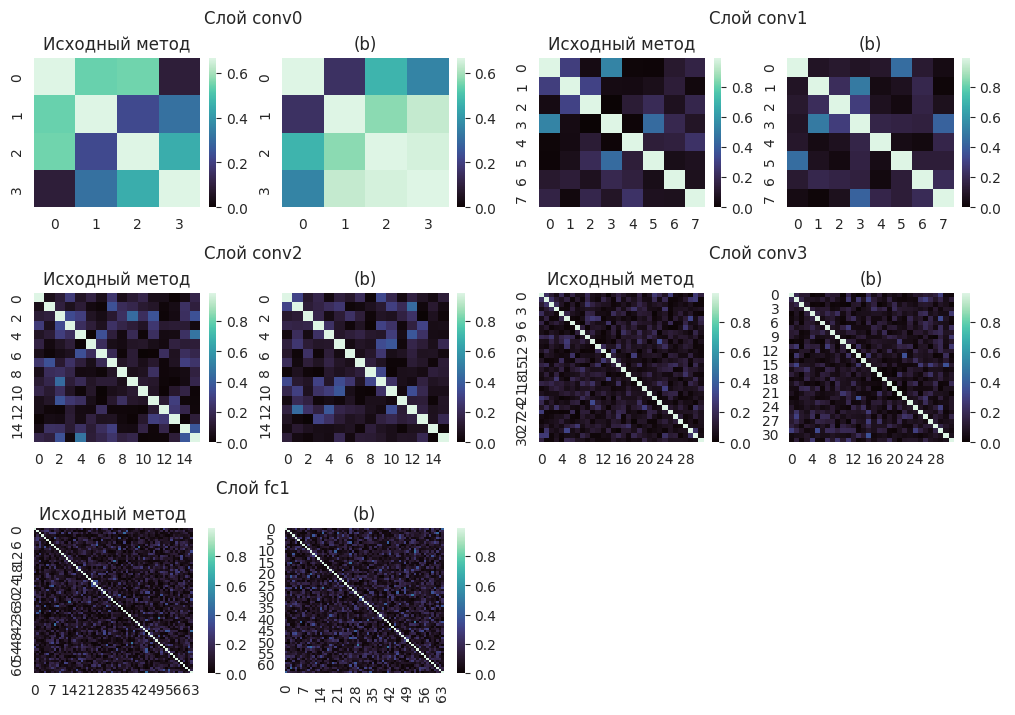

In [11]:
fig = plt.figure(constrained_layout=True, figsize=(10, 7))
# fig.suptitle('Матрицы Пирсона для сверток после предобучения baseline vs FeaturesCovariance')
subfigs = fig.subfigures(nrows=3, ncols=2)

with torch.no_grad():
    for i, layer in enumerate(model_pc.conv_layers):
        sup_ax = subfigs[i // 2][i % 2].subplots(1, 2)
        pm_bl = pearson_correlation_mat(model_baseline.get_submodule(f"{layer}").get_weight())
        pm_f_cov = pearson_correlation_mat(model_f_cov.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_bl.abs(), cmap="mako", vmin=0, ax=sup_ax[0])
        sup_ax[0].set_title("Исходный метод")
        sns.heatmap(pm_f_cov.abs(), cmap="mako", vmin=0, ax=sup_ax[1])
        sup_ax[1].set_title("(b)")
        subfigs[i // 2][i % 2].suptitle(f"Слой {layer}")

#### Карты признаков

In [7]:
import seaborn as sns
from PearsonCorrelation import pearson_correlation_mat
from torchvision import datasets
import torchvision.transforms as transforms

transformer_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(9),
        transforms.RandomCrop(32, 4),
        transforms.ToTensor(),
])
transformer_test = transforms.Compose([
        transforms.ToTensor(),
])

test_set = datasets.CIFAR10("./data", train=False, transform=transformer_test, download=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=100, shuffle=False)

len(test_loader)

100

In [27]:
bs_pc_dict = dict()
with torch.no_grad():
    for X, y in test_loader:
        for i, layer in enumerate(["pool1", "pool2", "pool3"]):
            model_baseline.cache_pooled_features(X)
            data = model_baseline.pf_caches[i][-1]

            mean_feat_of_maps = data.mean(dim=(2,3))
            mean_feat_of_maps_on_batch = mean_feat_of_maps.mean(dim=0)
            deviation_feat_of_maps = mean_feat_of_maps - mean_feat_of_maps_on_batch
            PoCor = (deviation_feat_of_maps.T @ deviation_feat_of_maps) / data.shape[0]
            bs_pc_dict[layer] = PoCor
        break
model_baseline.drop_pf_caches()

fcov_pc_dict = dict()
with torch.no_grad():
    for X, y in test_loader:
        for i, layer in enumerate(["pool1", "pool2", "pool3"]):
            model_f_cov.cache_pooled_features(X)
            data = model_f_cov.pf_caches[i][-1]

            mean_feat_of_maps = data.mean(dim=(2,3))
            mean_feat_of_maps_on_batch = mean_feat_of_maps.mean(dim=0)
            deviation_feat_of_maps = mean_feat_of_maps - mean_feat_of_maps_on_batch
            PoCor = (deviation_feat_of_maps.T @ deviation_feat_of_maps) / data.shape[0]
            fcov_pc_dict[layer] = PoCor
        break
model_f_cov.drop_pf_caches()

pc_pc_dict = dict()
with torch.no_grad():
    for X, y in test_loader:
        for i, layer in enumerate(["pool1", "pool2", "pool3"]):
            model_pc.cache_pooled_features(X)
            data = model_pc.pf_caches[i][-1]

            mean_feat_of_maps = data.mean(dim=(2,3))
            mean_feat_of_maps_on_batch = mean_feat_of_maps.mean(dim=0)
            deviation_feat_of_maps = mean_feat_of_maps - mean_feat_of_maps_on_batch
            PoCor = (deviation_feat_of_maps.T @ deviation_feat_of_maps) / data.shape[0]
            pc_pc_dict[layer] = PoCor
        break
model_pc.drop_pf_caches()

Text(-0.2, 0.5, 'c)')

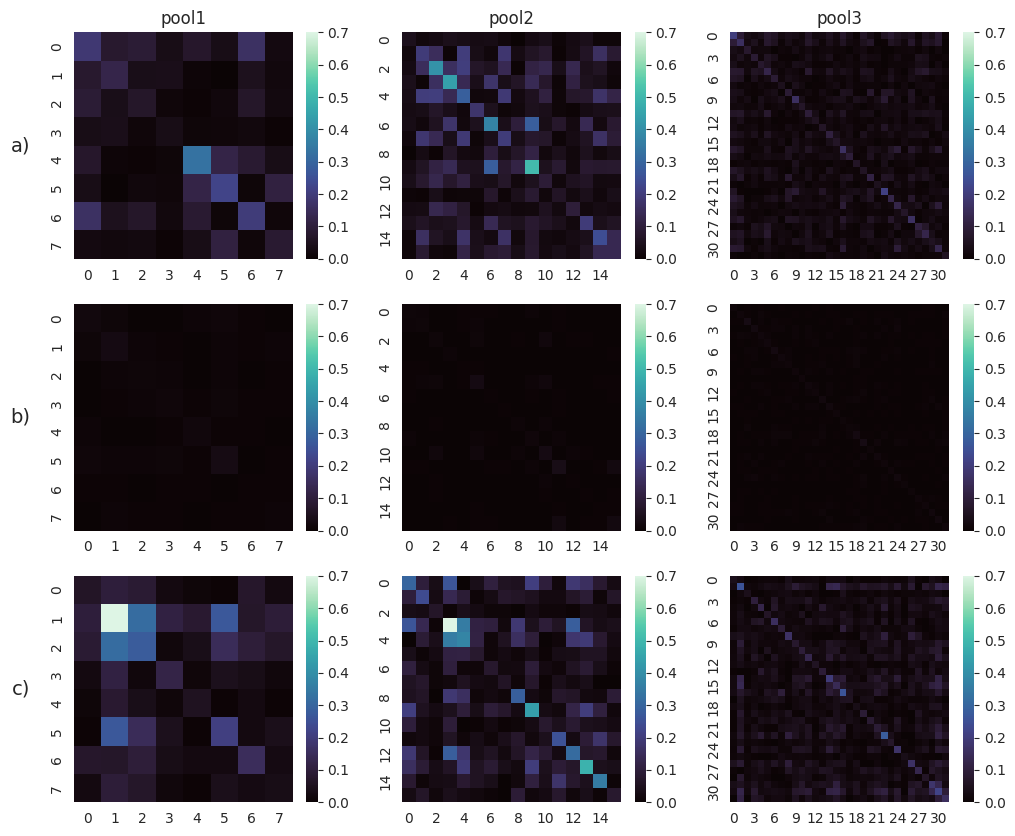

In [37]:
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 10))
# fig.suptitle('Матрицы Пирсона для сверток после предобучения baseline vs FeaturesCovariance')


for i, layer in enumerate(["pool1", "pool2", "pool3"]):
    pm_bl = bs_pc_dict[layer]
    sns.heatmap(pm_bl.abs(), cmap="mako", vmin=0, vmax=0.7, ax=axs[0][i])
    axs[0][i].set_title(layer)

    pm_fcov = fcov_pc_dict[layer]
    sns.heatmap(pm_fcov.abs(), cmap="mako", vmin=0, vmax=0.7,  ax=axs[1][i])
    # axs[1][i].set_title(layer)

    pm_pc = pc_pc_dict[layer]
    sns.heatmap(pm_pc.abs(), cmap="mako", vmin=0, vmax=0.7, ax=axs[2][i])
    # axs[1][i].set_title(layer)

axs[0][0].text(-0.2, 0.5, "a)", transform=axs[0][0].transAxes,
               ha="right", va="center", fontsize=14)

axs[1][0].text(-0.2, 0.5, "b)", transform=axs[1][0].transAxes,
               ha="right", va="center", fontsize=14)

axs[2][0].text(-0.2, 0.5, "c)", transform=axs[2][0].transAxes,
               ha="right", va="center", fontsize=14)

# CNN8

### Loss и Accuracy

#### Предобучение

In [84]:
f = open("statistics/CNN8_baseline_pretrain.json")
baseline_stat = json.load(f)

f = open("statistics/CNN8_pc_not_0_0.01_pretrain.json")
pc_stat = json.load(f)

f = open("statistics/CNN8_f_cov_pretrain.json")
f_cov_stat = json.load(f)

Text(0.5, 0.98, 'На тестовой выборке')

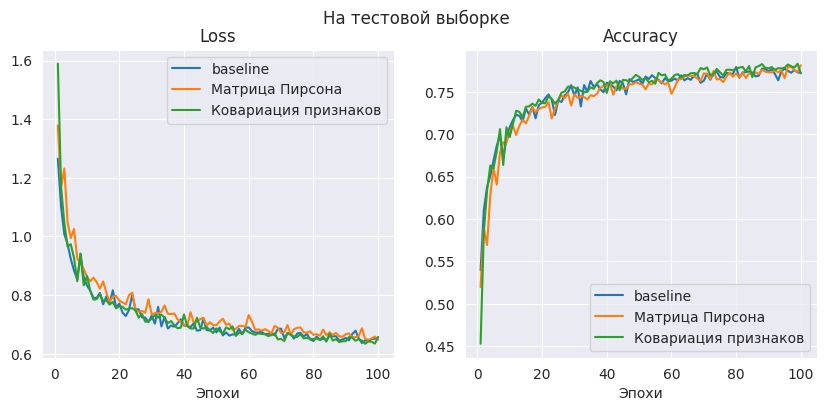

In [85]:
fix, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(baseline_stat['test_idx'], baseline_stat["test_loss"], label="baseline")
ax[0].plot(pc_stat['test_idx'], pc_stat["test_loss"], label="Матрица Пирсона")
ax[0].plot(f_cov_stat['test_idx'], f_cov_stat["test_loss"], label="Ковариация признаков")
ax[0].legend()
ax[0].set_title("Loss")
ax[0].set_xlabel("Эпохи")

ax[1].plot(baseline_stat['test_idx'], baseline_stat["test_accuracy"], label="baseline")
ax[1].plot(pc_stat['test_idx'], pc_stat["test_accuracy"], label="Матрица Пирсона")
ax[1].plot(f_cov_stat['test_idx'], f_cov_stat["test_accuracy"], label="Ковариация признаков")
ax[1].legend()
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Эпохи")

fix.suptitle("На тестовой выборке")

#### Дообучение

In [22]:
f = open("statistics/CNN8_baseline_quant.json")
baseline_stat = json.load(f)

f = open("statistics/CNN8_pc_not_0_quant.json")
pc_stat = json.load(f)

f = open("statistics/CNN8_f_cov_quant.json")
f_cov_stat = json.load(f)

Text(0.5, 0.98, 'На тестовой выборке')

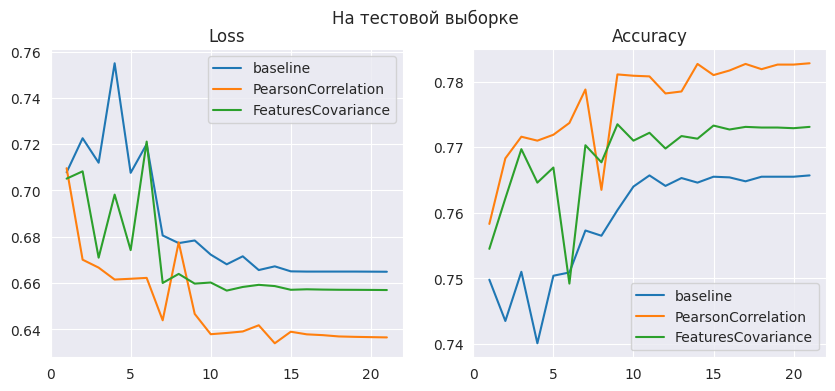

In [23]:
fix, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(baseline_stat['test_idx'], baseline_stat["test_loss"], label="baseline")
ax[0].plot(pc_stat['test_idx'], pc_stat["test_loss"], label="PearsonCorrelation")
ax[0].plot(f_cov_stat['test_idx'], f_cov_stat["test_loss"], label="FeaturesCovariance")
ax[0].legend()
ax[0].set_title("Loss")

ax[1].plot(baseline_stat['test_idx'], baseline_stat["test_accuracy"], label="baseline")
ax[1].plot(pc_stat['test_idx'], pc_stat["test_accuracy"], label="PearsonCorrelation")
ax[1].plot(f_cov_stat['test_idx'], f_cov_stat["test_accuracy"], label="FeaturesCovariance")
ax[1].legend()
ax[1].set_title("Accuracy")

fix.suptitle("На тестовой выборке")

### Corrls

#### Предобучение

In [73]:
f = open("statistics/CNN8_baseline_pretrain_corrls_L.json")
baseline_stat = json.load(f)

f = open("statistics/CNN8_pc_not_0_0.01_pretrain_corrls_L.json")
pc_stat = json.load(f)

f = open("statistics/CNN8_f_cov_pretrain_corrls_L.json")
f_cov_stat = json.load(f)

In [74]:
conv_layers = ["conv0", "conv1_1", "conv1_2", "conv2", "conv3_1", "conv3_2", "fc1"]

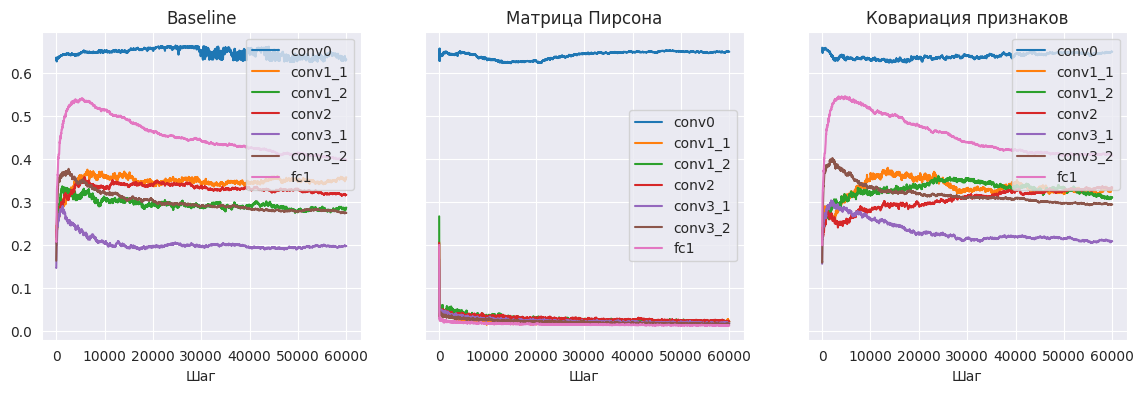

In [77]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
# fig.suptitle("Corrs_L для слоев")

axs[0].set_title("Baseline")
for i, layer_name in enumerate(conv_layers):
    axs[0].plot(baseline_stat["corrs_l"][i], label=layer_name)
axs[0].legend()
axs[0].set_xlabel("Шаг")

axs[1].set_title("Матрица Пирсона")
for i, layer_name in enumerate(conv_layers):
    axs[1].plot(pc_stat["corrs_l"][i], label=layer_name)
axs[1].legend()
axs[1].set_xlabel("Шаг")

axs[2].set_title("Ковариация признаков")
for i, layer_name in enumerate(conv_layers):
    axs[2].plot(f_cov_stat["corrs_l"][i], label=layer_name)
axs[2].legend()
axs[2].set_xlabel("Шаг")

print()

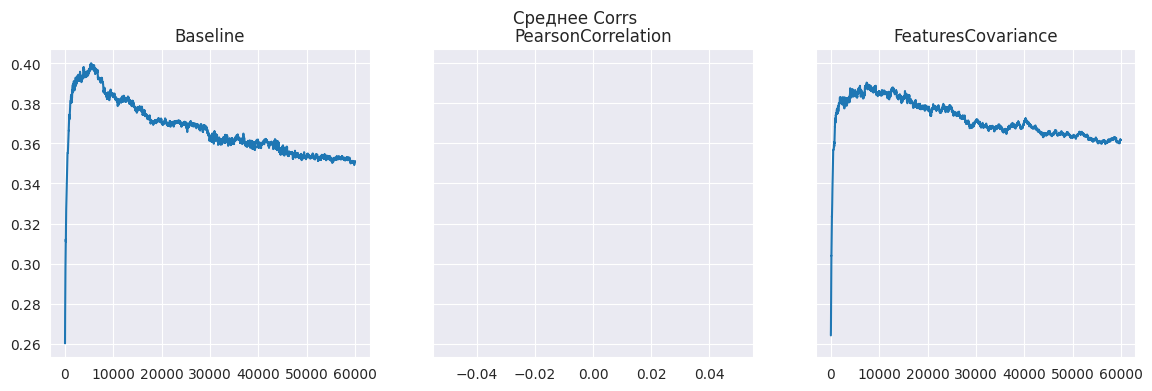

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Среднее Corrs")

axs[0].set_title("Baseline")
axs[0].plot(baseline_stat["mean_corrs"])

axs[1].set_title("PearsonCorrelation")
axs[1].plot(pc_stat["mean_corrs"])

axs[2].set_title("FeaturesCovariance")
axs[2].plot(f_cov_stat["mean_corrs"])

print()

## Проекции

### Матрицы Пирсона

#### Предобучение

In [86]:
from cifar_models import CNN8
import torch

model_baseline = CNN8()
model_baseline.load_state_dict(torch.load("models/CNN8_baseline_pretrain.pt", weights_only=True))
model_baseline.eval()

model_pc = CNN8()
model_pc.load_state_dict(torch.load("models/CNN8_pc_not_0_0.01_pretrain.pt", weights_only=True))
model_pc.eval()

model_f_cov = CNN8()
model_f_cov.load_state_dict(torch.load("models/CNN8_f_cov_pretrain.pt", weights_only=True))
model_f_cov.eval()

print()

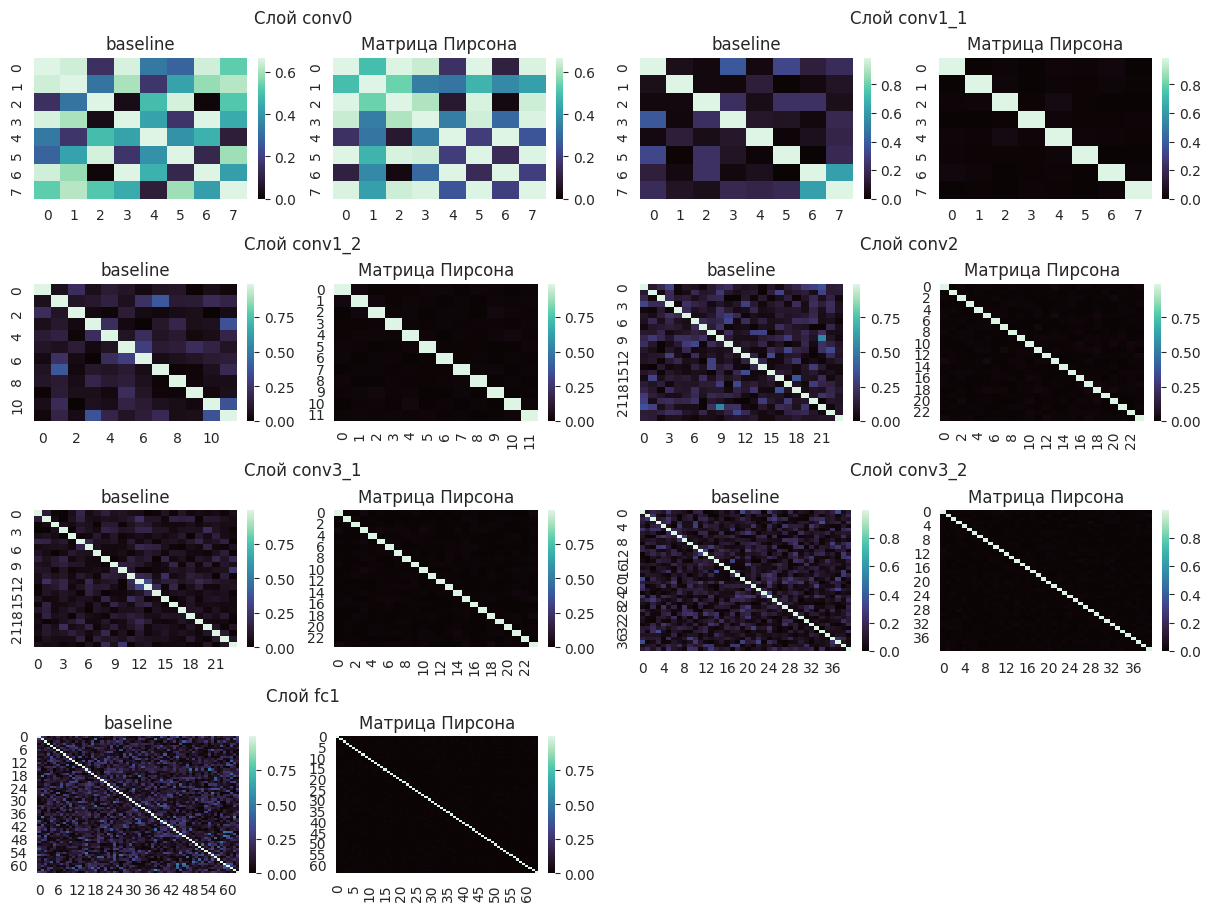

In [69]:
import seaborn as sns
from PearsonCorrelation import pearson_correlation_mat

fig = plt.figure(constrained_layout=True, figsize=(12, 9))
# fig.suptitle('Матрицы Пирсона для сверток после предобучения baseline vs PearsonCorrelation')
subfigs = fig.subfigures(nrows=4, ncols=2)

with torch.no_grad():
    for i, layer in enumerate(model_pc.conv_layers):
        sup_ax = subfigs[i // 2][i % 2].subplots(1, 2)
        pm_bl = pearson_correlation_mat(model_baseline.get_submodule(f"{layer}").get_weight())
        pm_pc = pearson_correlation_mat(model_pc.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_bl.abs(), cmap="mako", vmin=0, ax=sup_ax[0])
        sup_ax[0].set_title("baseline")
        sns.heatmap(pm_pc.abs(), cmap="mako", vmin=0, ax=sup_ax[1])
        sup_ax[1].set_title("Матрица Пирсона")
        subfigs[i // 2][i % 2].suptitle(f"Слой {layer}")

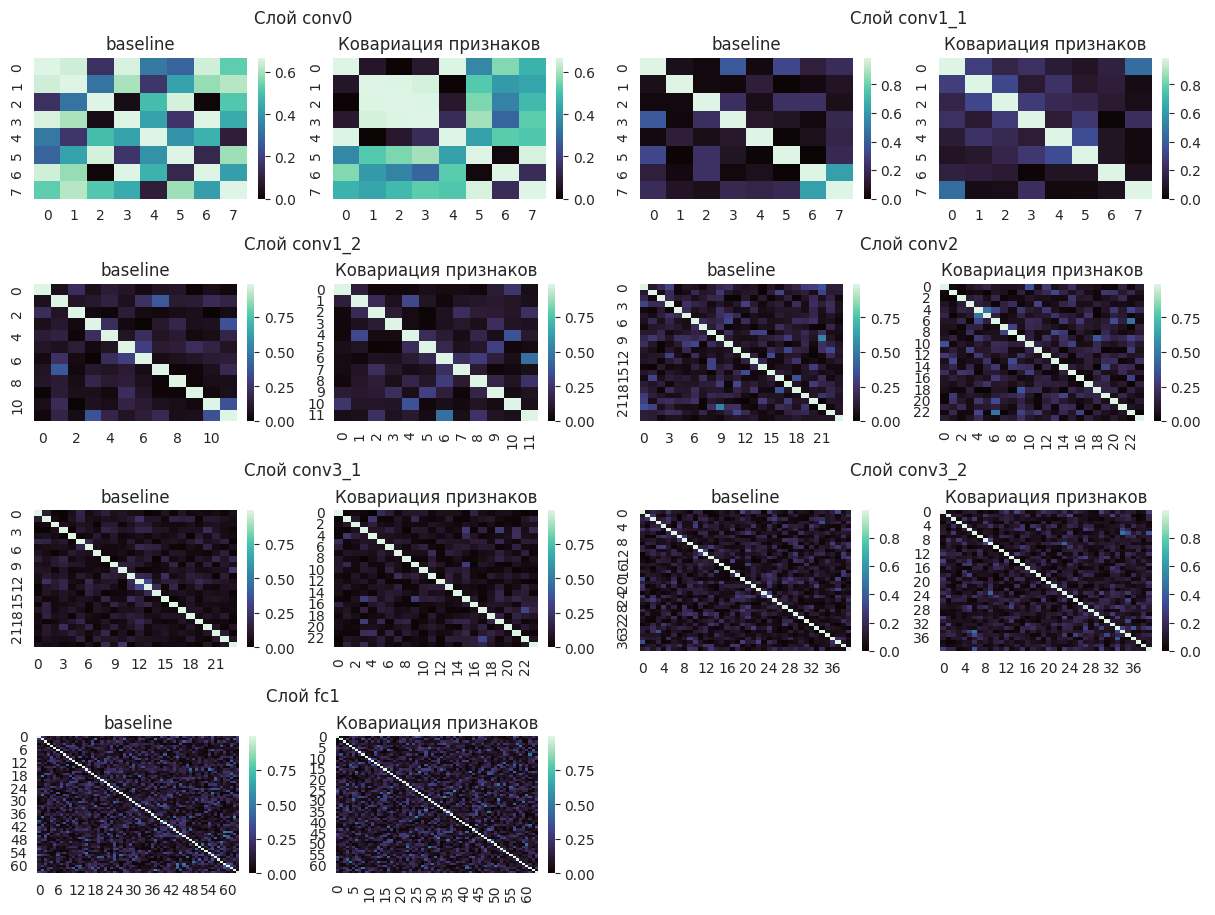

In [87]:
fig = plt.figure(constrained_layout=True, figsize=(12, 9))
# fig.suptitle('Матрицы Пирсона для сверток после предобучения baseline vs FeaturesCovariance')
subfigs = fig.subfigures(nrows=4, ncols=2)

with torch.no_grad():
    for i, layer in enumerate(model_pc.conv_layers):
        sup_ax = subfigs[i // 2][i % 2].subplots(1, 2)
        pm_bl = pearson_correlation_mat(model_baseline.get_submodule(f"{layer}").get_weight())
        pm_f_cov = pearson_correlation_mat(model_f_cov.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_bl.abs(), cmap="mako", vmin=0, ax=sup_ax[0])
        sup_ax[0].set_title("baseline")
        sns.heatmap(pm_f_cov.abs(), cmap="mako", vmin=0, ax=sup_ax[1])
        sup_ax[1].set_title("Ковариация признаков")
        subfigs[i // 2][i % 2].suptitle(f"Слой {layer}")

# CNN10

### Loss и Accuracy

#### Предобучение

In [89]:
f = open("statistics/CNN10_baseline_pretrain.json")
baseline_stat = json.load(f)

f = open("statistics/CNN10_pc_not_0_0.001_pretrain.json")
pc_stat = json.load(f)

f = open("statistics/CNN10_f_cov_pretrain.json")
f_cov_stat = json.load(f)

Text(0.5, 0.98, 'На тестовой выборке')

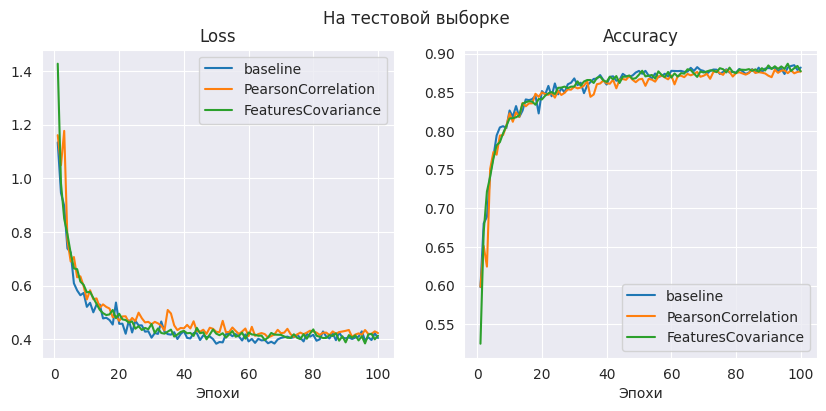

In [90]:
fix, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(baseline_stat['test_idx'], baseline_stat["test_loss"], label="baseline")
ax[0].plot(pc_stat['test_idx'], pc_stat["test_loss"], label="PearsonCorrelation")
ax[0].plot(f_cov_stat['test_idx'], f_cov_stat["test_loss"], label="FeaturesCovariance")
ax[0].legend()
ax[0].set_title("Loss")
ax[0].set_xlabel("Эпохи")

ax[1].plot(baseline_stat['test_idx'], baseline_stat["test_accuracy"], label="baseline")
ax[1].plot(pc_stat['test_idx'], pc_stat["test_accuracy"], label="PearsonCorrelation")
ax[1].plot(f_cov_stat['test_idx'], f_cov_stat["test_accuracy"], label="FeaturesCovariance")
ax[1].legend()
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Эпохи")

fix.suptitle("На тестовой выборке")


#### Дообучение

In [36]:
f = open("statistics/CNN10_baseline_quant.json")
baseline_stat = json.load(f)

f = open("statistics/CNN10_pc_not_0_quant.json")
pc_stat = json.load(f)

f = open("statistics/CNN10_f_cov_quant.json")
f_cov_stat = json.load(f)

Text(0.5, 0.98, 'На тестовой выборке')

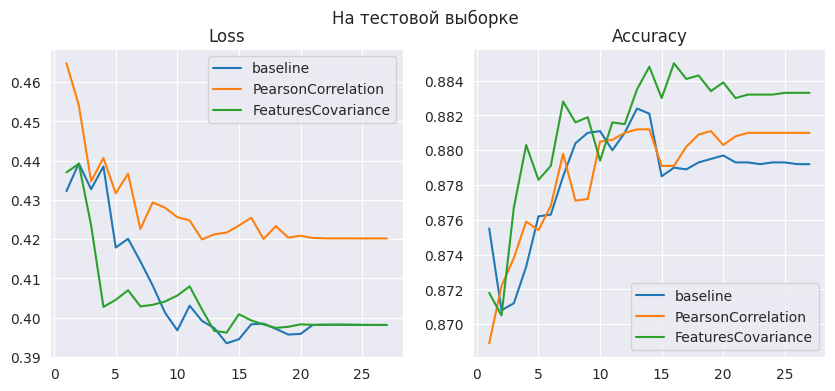

In [37]:
fix, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(baseline_stat['test_idx'], baseline_stat["test_loss"], label="baseline")
ax[0].plot(pc_stat['test_idx'], pc_stat["test_loss"], label="PearsonCorrelation")
ax[0].plot(f_cov_stat['test_idx'], f_cov_stat["test_loss"], label="FeaturesCovariance")
ax[0].legend()
ax[0].set_title("Loss")

ax[1].plot(baseline_stat['test_idx'], baseline_stat["test_accuracy"], label="baseline")
ax[1].plot(pc_stat['test_idx'], pc_stat["test_accuracy"], label="PearsonCorrelation")
ax[1].plot(f_cov_stat['test_idx'], f_cov_stat["test_accuracy"], label="FeaturesCovariance")
ax[1].legend()
ax[1].set_title("Accuracy")

fix.suptitle("На тестовой выборке")

### Corrls

#### Предобучение

In [93]:
f = open("statistics/CNN10_baseline_pretrain_corrls_L.json")
baseline_stat = json.load(f)

f = open("statistics/CNN10_pc_not_0_0.001_pretrain_corrls_L.json")
pc_stat = json.load(f)

f = open("statistics/CNN10_f_cov_pretrain_corrls_L.json")
f_cov_stat = json.load(f)

In [94]:
conv_layers = ["conv0", "conv1_1", "conv1_2", "conv2_1", "conv2_2", "conv3_1", "conv3_2", "conv3_3", "fc1"]

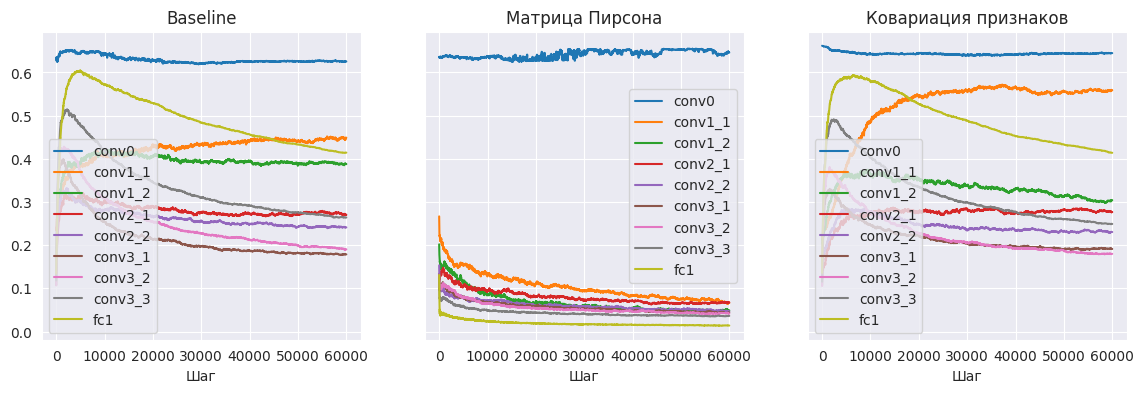

In [97]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
# fig.suptitle("Corrs_L для слоев")

axs[0].set_title("Baseline")
for i, layer_name in enumerate(conv_layers):
    axs[0].plot(baseline_stat["corrs_l"][i], label=layer_name)
axs[0].legend()
axs[0].set_xlabel("Шаг")

axs[1].set_title("Матрица Пирсона")
for i, layer_name in enumerate(conv_layers):
    axs[1].plot(pc_stat["corrs_l"][i], label=layer_name)
axs[1].legend()
axs[1].set_xlabel("Шаг")

axs[2].set_title("Ковариация признаков")
for i, layer_name in enumerate(conv_layers):
    axs[2].plot(f_cov_stat["corrs_l"][i], label=layer_name)
axs[2].legend()
axs[2].set_xlabel("Шаг")

print()

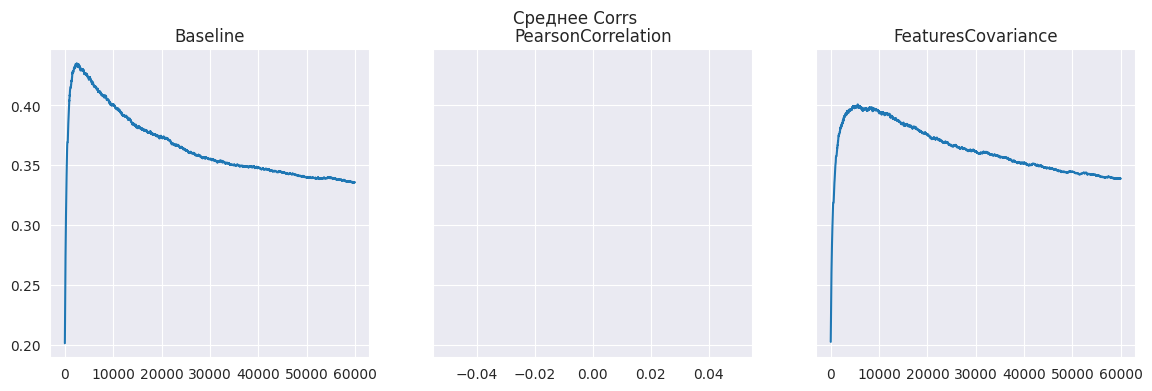

In [41]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Среднее Corrs")

axs[0].set_title("Baseline")
axs[0].plot(baseline_stat["mean_corrs"])

axs[1].set_title("PearsonCorrelation")
axs[1].plot(pc_stat["mean_corrs"])

axs[2].set_title("FeaturesCovariance")
axs[2].plot(f_cov_stat["mean_corrs"])

print()

### Матрицы Пирсона


#### Предобучение

In [101]:
from cifar_models import CNN10
import torch

model_baseline = CNN10()
model_baseline.load_state_dict(torch.load("models/CNN10_baseline_pretrain.pt", weights_only=True))
model_baseline.eval()

model_pc = CNN10()
model_pc.load_state_dict(torch.load("models/CNN10_pc_not_0_0.001_pretrain.pt", weights_only=True))
model_pc.eval()

model_f_cov = CNN10()
model_f_cov.load_state_dict(torch.load("models/CNN10_f_cov_pretrain.pt", weights_only=True))
model_f_cov.eval()

print()

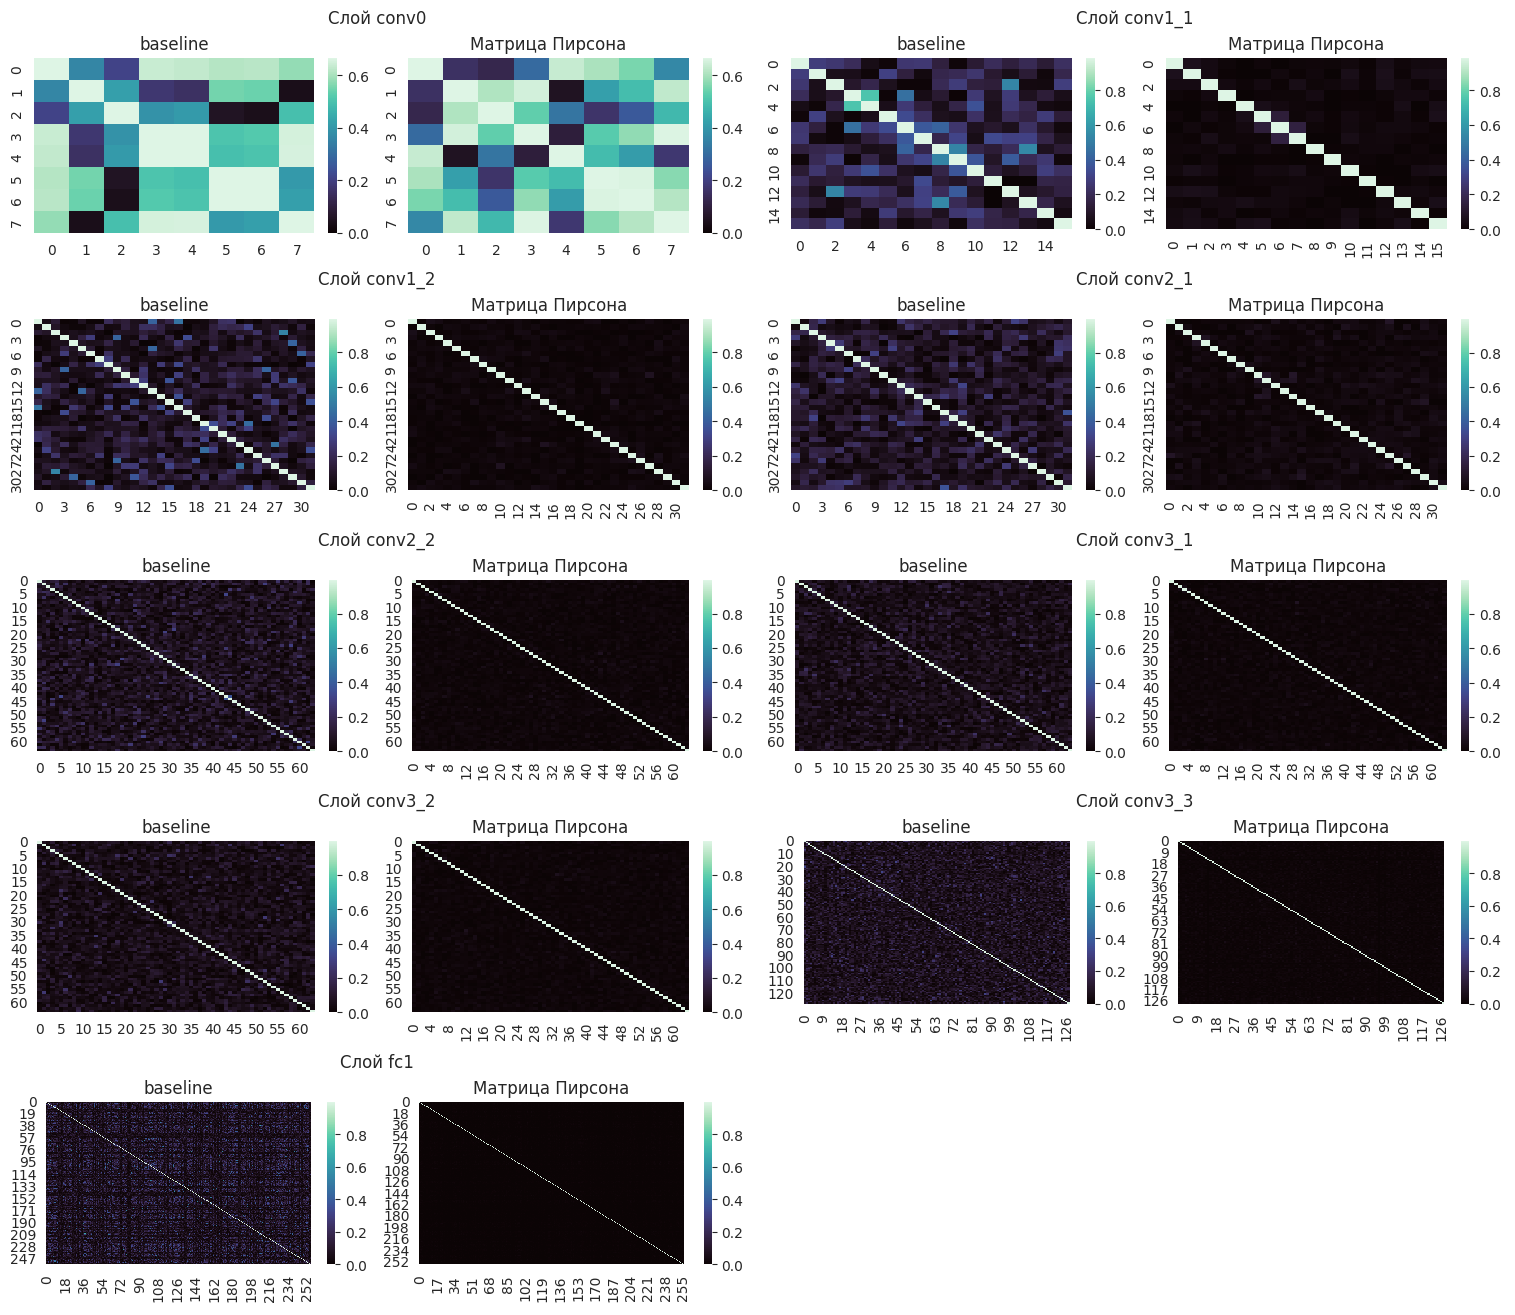

In [102]:
import seaborn as sns
from PearsonCorrelation import pearson_correlation_mat

fig = plt.figure(constrained_layout=True, figsize=(15, 13))
# fig.suptitle('Матрицы Пирсона для сверток после предобучения baseline vs PearsonCorrelation')
subfigs = fig.subfigures(nrows=5, ncols=2)

with torch.no_grad():
    for i, layer in enumerate(model_pc.conv_layers):
        sup_ax = subfigs[i // 2][i % 2].subplots(1, 2)
        pm_bl = pearson_correlation_mat(model_baseline.get_submodule(f"{layer}").get_weight())
        pm_pc = pearson_correlation_mat(model_pc.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_bl.abs(), cmap="mako", vmin=0, ax=sup_ax[0])
        sup_ax[0].set_title("baseline")
        sns.heatmap(pm_pc.abs(), cmap="mako", vmin=0, ax=sup_ax[1])
        sup_ax[1].set_title("Матрица Пирсона")
        subfigs[i // 2][i % 2].suptitle(f"Слой {layer}")

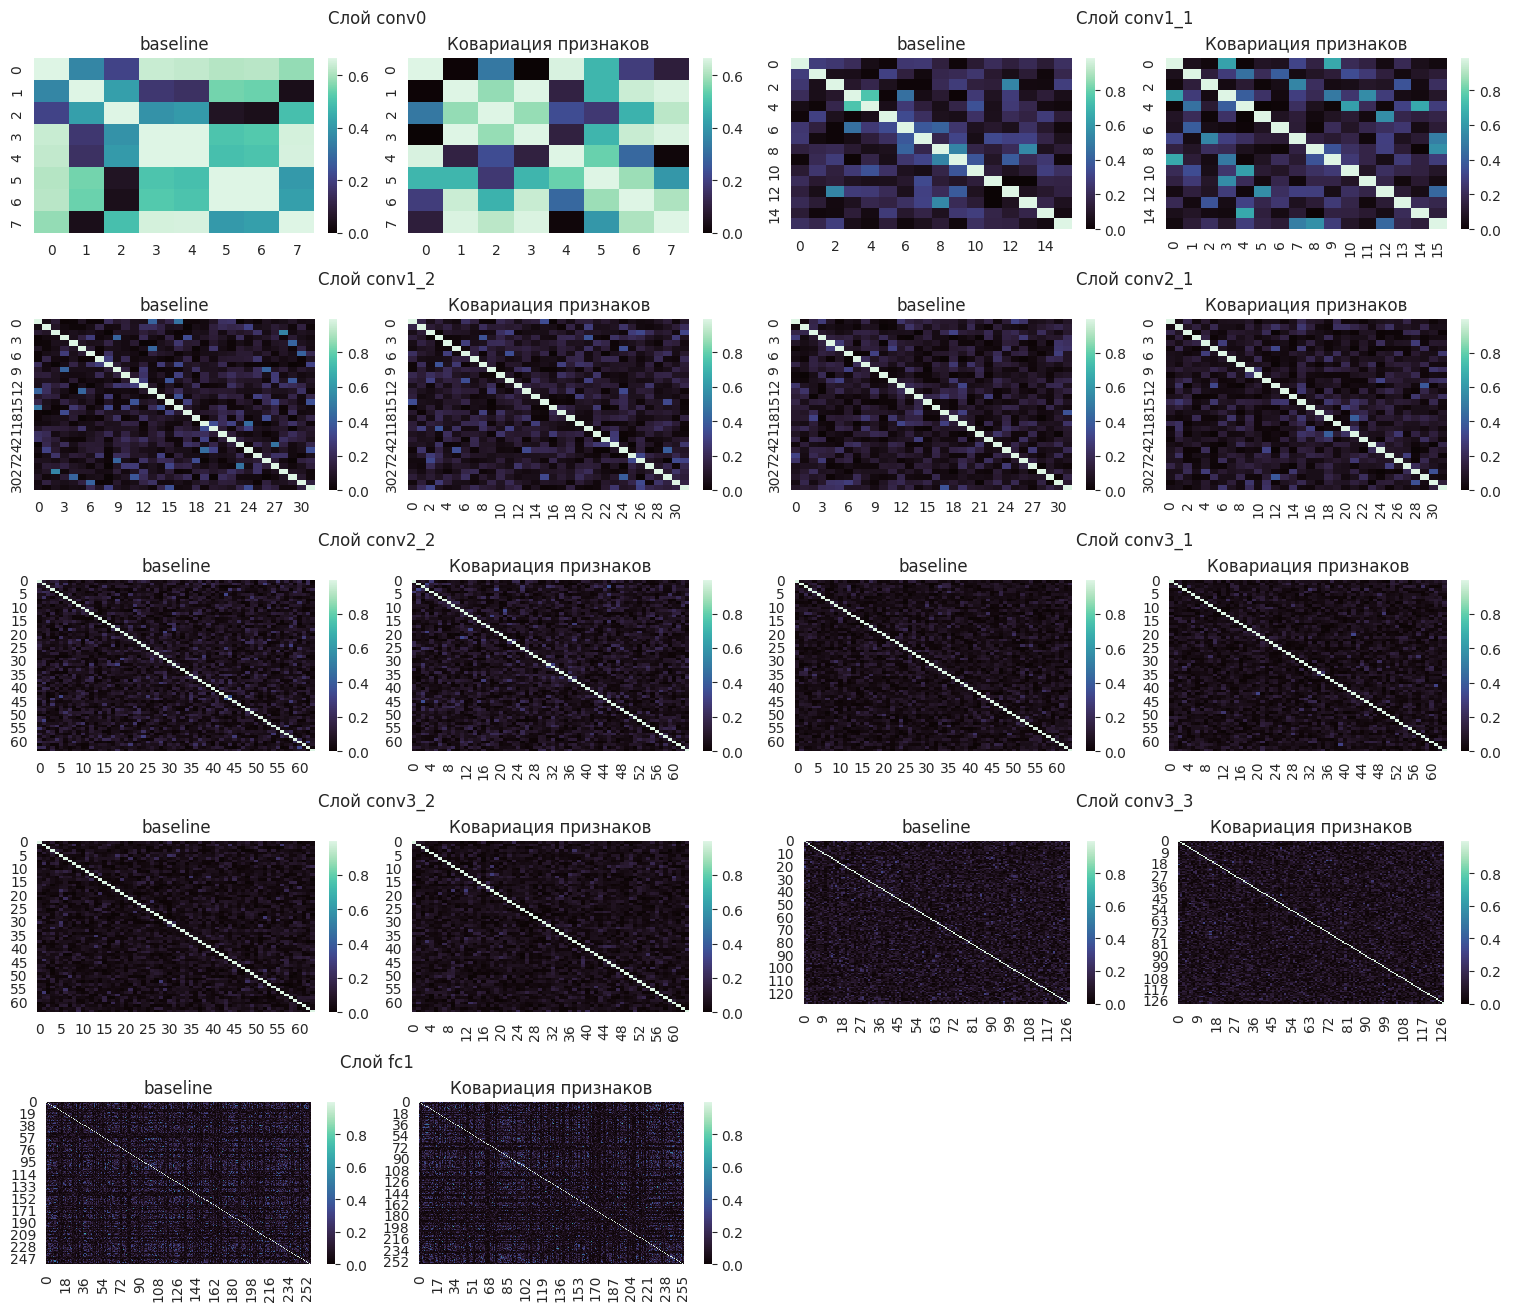

In [104]:
fig = plt.figure(constrained_layout=True, figsize=(15, 13))
# fig.suptitle('Матрицы Пирсона для сверток после предобучения baseline vs FeaturesCovariance')
subfigs = fig.subfigures(nrows=5, ncols=2)

with torch.no_grad():
    for i, layer in enumerate(model_pc.conv_layers):
        sup_ax = subfigs[i // 2][i % 2].subplots(1, 2)
        pm_bl = pearson_correlation_mat(model_baseline.get_submodule(f"{layer}").get_weight())
        pm_f_cov = pearson_correlation_mat(model_f_cov.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_bl.abs(), cmap="mako", vmin=0, ax=sup_ax[0])
        sup_ax[0].set_title("baseline")
        sns.heatmap(pm_f_cov.abs(), cmap="mako", vmin=0, ax=sup_ax[1])
        sup_ax[1].set_title("Ковариация признаков")
        subfigs[i // 2][i % 2].suptitle(f"Слой {layer}")